In [ ]:
!pip install PyPDF2 Pillow tabulate rich

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.0 MB/s eta 0:00:00


In [ ]:
!pip install -q pymupdf4llm langchain langchain-text-splitters tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 18.1 MB/s eta 0:00:00


In [ ]:
!pip install -U pymupdf

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
!pip install -q docling
!pip install -U transformers huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.0/494.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.9/93.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 813.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 13.4 MB/s eta 0:00:00
   ━━

In [ ]:
import os
import nest_asyncio
from llama_parse import LlamaParse
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_core.documents import Document
from tqdm.notebook import tqdm

/tmp/ipython-input-2869670929.py:3: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  from llama_parse import LlamaParse


#  book splitting

In [ ]:
import fitz
import os

def split_pdf_for_llama(input_path, output_dir, number_of_parts=4):
    if not os.path.exists(input_path):
        print(f"Error: Could not find {input_path}")
        return

    print(f"Opening high-quality PDF: {input_path}...")
    doc = fitz.open(input_path)
    total_pages = len(doc)

    # Calculate how many pages go into each chunk
    pages_per_chunk = total_pages // number_of_parts

    os.makedirs(output_dir, exist_ok=True)
    print("-" * 40)

    for i in range(number_of_parts):
        start_page = i * pages_per_chunk
        # Ensure the final part grabs any leftover pages at the end
        end_page = total_pages - 1 if i == number_of_parts - 1 else (start_page + pages_per_chunk - 1)

        # Create a new empty PDF for this chunk
        new_doc = fitz.open()
        # Copy the page range from the original document
        new_doc.insert_pdf(doc, from_page=start_page, to_page=end_page)

        # Save the new chunk
        part_num = i + 1
        output_file = os.path.join(output_dir, f"clinical-sports-medicine_Part{part_num}.pdf")

        # Save with light garbage collection just to keep it tidy
        new_doc.save(output_file, garbage=3, deflate=True)
        new_doc.close()

        # Report the new file size
        size_mb = os.path.getsize(output_file) / (1024 * 1024)
        print(f"✅ Part {part_num} (Pages {start_page} to {end_page}): {size_mb:.2f} MB")

    print("-" * 40)
    print("Splitting complete! These files are now ready for LlamaParse.")

# --- USAGE ---
# Point this to the 331 MB version you created earlier with the /ebook setting
input_pdf = "/content/drive/MyDrive/sport_book/pdfcoffee.com_clinical-sports-medicine-4th-edition-brukner-khan-4-pdf-free.pdf"
output_folder = "book_reduction/split_volumes"

split_pdf_for_llama(input_pdf, output_folder, number_of_parts=4)

Opening high-quality PDF: /content/drive/MyDrive/sport_book/pdfcoffee.com_clinical-sports-medicine-4th-edition-brukner-khan-4-pdf-free.pdf...
----------------------------------------
✅ Part 1 (Pages 0 to 334): 81.21 MB
✅ Part 2 (Pages 335 to 669): 83.30 MB
✅ Part 3 (Pages 670 to 1004): 82.96 MB
✅ Part 4 (Pages 1005 to 1341): 88.49 MB
----------------------------------------
Splitting complete! These files are now ready for LlamaParse.


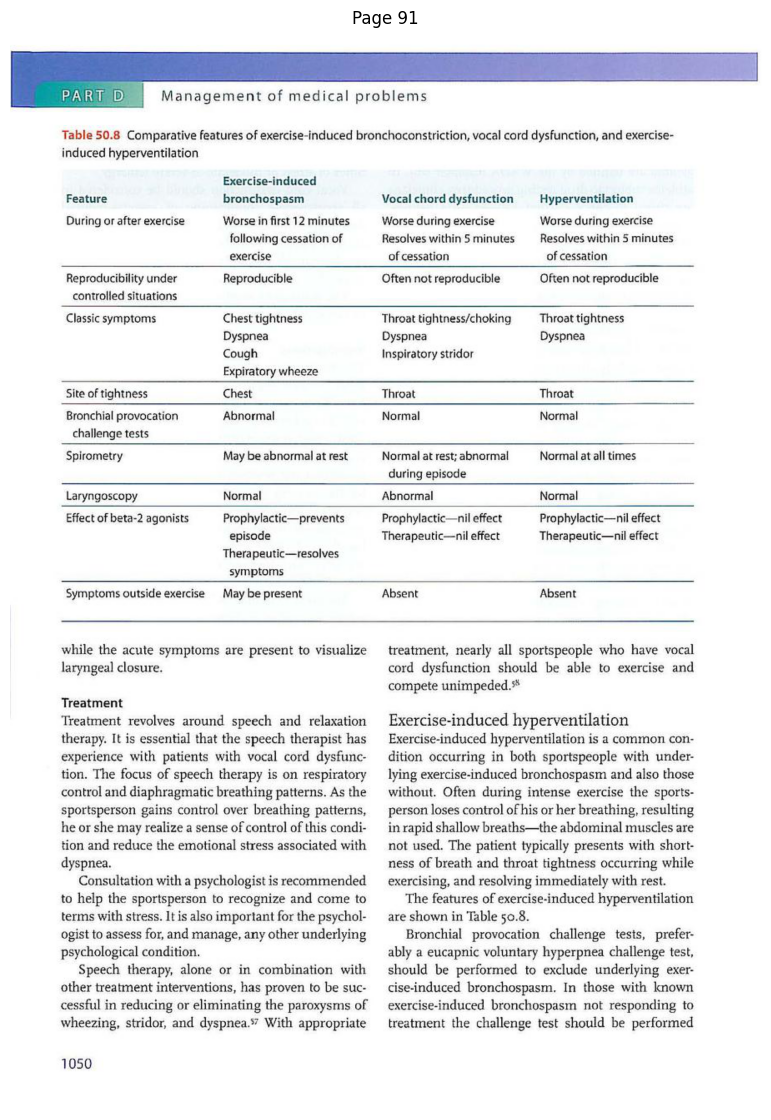

In [ ]:
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import numpy as np


def display_pdf_page(pdf_path, page_number=0, zoom=2.5, grayscale=False):
    """
    pdf_path: path to pdf file
    page_number: zero-based index (0 = first page)
    zoom: increase for higher resolution (2.0 - 4.0 recommended)
    grayscale: True to display in grayscale
    """

    doc = fitz.open(pdf_path)

    if page_number < 0 or page_number >= len(doc):
        print("Invalid page number")
        return

    page = doc[page_number]

    # Increase resolution
    matrix = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=matrix)

    img = np.frombuffer(pix.samples, dtype=np.uint8)
    img = img.reshape(pix.height, pix.width, pix.n)

    if grayscale and pix.n == 3:
        img = img.mean(axis=2)

    plt.figure(figsize=(10, 14))
    plt.imshow(img, cmap="gray" if grayscale else None)
    plt.axis("off")
    plt.title(f"Page {page_number + 1}")
    plt.show()

    doc.close()


pdf_path = "/content/book_reduction/split_volumes/clinical-sports-medicine_Part4.pdf"

display_pdf_page(pdf_path, page_number=90, zoom=10, grayscale=False)


In [ ]:
import shutil
import os

def copy_directory(src_dir, dst_dir):
    if not os.path.exists(src_dir):
        print(f"Source directory not found: {src_dir}")
        return

    os.makedirs(os.path.dirname(dst_dir), exist_ok=True)

    shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)
    print("Copy completed successfully.")


source_directory = "/content/book_reduction"
destination_directory = "/content/drive/MyDrive/sport_book"

copy_directory(source_directory, destination_directory)


Copy completed successfully.


In [ ]:

folder_book="/content/book_reduction/split_volumes"

book_split_list=[os.path.join(folder_book,f) for f in os.listdir(folder_book)]
book_split_list


['/content/book_reduction/split_volumes/clinical-sports-medicine_Part4.pdf',
 '/content/book_reduction/split_volumes/clinical-sports-medicine_Part3.pdf',
 '/content/book_reduction/split_volumes/clinical-sports-medicine_Part1.pdf',
 '/content/book_reduction/split_volumes/clinical-sports-medicine_Part2.pdf']

In [ ]:
book_list = [
    "/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part1.pdf",
    "/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part2.pdf",
    "/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part3.pdf",
    "/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part4.pdf",
    "/content/drive/MyDrive/sport_book/Nancy_Clark_s_Sports_Nutrition_Guidebook.pdf",
    "/content/drive/MyDrive/sport_book/essentials-of-strength-training-and-conditioning_compress.pdf",]

In [ ]:
books=[]
for book in book_list:
  books.append({"path":book})

books

[{'path': '/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part1.pdf'},
 {'path': '/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part2.pdf'},
 {'path': '/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part3.pdf'},
 {'path': '/content/drive/MyDrive/sport_book/split_volumes/clinical-sports-medicine_Part4.pdf'},
 {'path': '/content/drive/MyDrive/sport_book/Nancy_Clark_s_Sports_Nutrition_Guidebook.pdf'},
 {'path': '/content/drive/MyDrive/sport_book/essentials-of-strength-training-and-conditioning_compress.pdf'}]

# copy the books after split from the drive to the colab

In [ ]:

import os
import shutil

org_path="/content/drive/MyDrive/SPORT_METADATA/unstructured data/sport_book/original-books"
dist_path="/content/books"

os.makedirs(dist_path,exist_ok=True)

shutil.copytree(org_path,dist_path,dirs_exist_ok=True)

'/content/books'

In [ ]:
import os
import re
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
import PyPDF2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set the path to your books
books_path = "/content/books"

def get_file_size(size_bytes):
    """Convert bytes to human readable format"""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if size_bytes < 1024.0:
            return f"{size_bytes:.2f} {unit}"
        size_bytes /= 1024.0
    return f"{size_bytes:.2f} TB"

def get_pdf_page_count(pdf_path):
    """Get number of pages in PDF"""
    try:
        with open(pdf_path, 'rb') as file:
            pdf_reader = PyPDF2.PdfReader(file)
            return len(pdf_reader.pages)
    except:
        return "N/A"

def get_image_info(img_path):
    """Get image dimensions"""
    try:
        with Image.open(img_path) as img:
            return f"{img.width}x{img.height}"
    except:
        return "N/A"

def count_words_in_txt(txt_path):
    """Count words in text file"""
    try:
        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as file:
            content = file.read()
            return len(content.split())
    except:
        return "N/A"

# Collect book information
books_data = []
total_size = 0
file_types = {}

for root, dirs, files in os.walk(books_path):
    for file in files:
        file_path = os.path.join(root, file)
        file_size = os.path.getsize(file_path)
        total_size += file_size

        # Get file extension
        ext = Path(file).suffix.lower()
        file_types[ext] = file_types.get(ext, 0) + 1

        # Basic info
        book_info = {
            '📚 Book Name': Path(file).stem[:50] + ('...' if len(Path(file).stem) > 50 else ''),
            '📄 Format': ext,
            '📏 Size': get_file_size(file_size),
            '📁 Folder': Path(root).name,
        }

        # Format-specific details
        if ext == '.pdf':
            book_info['📖 Pages'] = get_pdf_page_count(file_path)
        elif ext in ['.txt', '.md', '.rtf']:
            book_info['📝 Words'] = count_words_in_txt(file_path)
        elif ext in ['.jpg', '.jpeg', '.png', '.gif', '.bmp']:
            book_info['🖼️ Resolution'] = get_image_info(file_path)
        elif ext in ['.epub', '.mobi']:
            book_info['📖 Format'] = 'eBook'

        books_data.append(book_info)

# Create DataFrame
df = pd.DataFrame(books_data)

# Sort by size (convert to bytes for proper sorting)
df['_size_bytes'] = [os.path.getsize(os.path.join(root, file)) for root, dirs, files in os.walk(books_path) for file in files]
df = df.sort_values('_size_bytes', ascending=False).drop('_size_bytes', axis=1)

# Display summary statistics
print("=" * 80)
print("📊 BOOK COLLECTION SUMMARY")
print("=" * 80)

# Summary cards
total_files = len(books_data)
summary_html = f"""
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; margin: 10px 0;">
    <table style="width: 100%; color: white; font-size: 16px;">
        <tr>
            <td style="padding: 10px;"><strong>📚 Total Books:</strong></td>
            <td style="padding: 10px;">{total_files} files</td>
            <td style="padding: 10px;"><strong>💾 Total Size:</strong></td>
            <td style="padding: 10px;">{get_file_size(total_size)}</td>
        </tr>
        <tr>
            <td style="padding: 10px;"><strong>📁 Folders:</strong></td>
            <td style="padding: 10px;">{len(set([Path(root).name for root, dirs, files in os.walk(books_path)]))}</td>
            <td style="padding: 10px;"><strong>📄 Formats:</strong></td>
            <td style="padding: 10px;">{len(file_types)} types</td>
        </tr>
    </table>
</div>
"""
display(HTML(summary_html))

# Format distribution
print("\n📄 FILE FORMAT DISTRIBUTION:")
print("-" * 40)
format_df = pd.DataFrame(list(file_types.items()), columns=['Format', 'Count'])
format_df = format_df.sort_values('Count', ascending=False)
for _, row in format_df.iterrows():
    bar_length = int(row['Count'] / max(file_types.values()) * 30)
    bar = "█" * bar_length + "░" * (30 - bar_length)
    print(f"{row['Format']:10} {bar} {row['Count']:3} files")

# Display the main table with styling
print("\n" + "=" * 80)
print("📖 DETAILED BOOK LIST (Sorted by Size)")
print("=" * 80)

# Style the DataFrame
styled_df = df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'border-color': '#dee2e6',
    'border-style': 'solid',
    'border-width': '1px',
    'padding': '8px',
    'text-align': 'left'
}).set_table_styles([
    {'selector': 'thead th',
     'props': [('background-color', '#4a90e2'),
               ('color', 'white'),
               ('font-weight', 'bold'),
               ('padding', '10px'),
               ('text-align', 'left')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#e3f2fd')]}
])

display(styled_df)


📊 BOOK COLLECTION SUMMARY


📚 Total Books:,7 files,💾 Total Size:,723.36 MB
📁 Folders:,1,📄 Formats:,1 types



📄 FILE FORMAT DISTRIBUTION:
----------------------------------------
.pdf       ██████████████████████████████   7 files

📖 DETAILED BOOK LIST (Sorted by Size)


,📚 Book Name,📄 Format,📏 Size,📁 Folder,📖 Pages
5,pdfcoffee.com_clinical-sports-medicine-4th-edition...,.pdf,336.67 MB,books,1342
6,clinical-sports-medicine_Part4,.pdf,88.49 MB,books,337
4,clinical-sports-medicine_Part2,.pdf,83.30 MB,books,335
2,clinical-sports-medicine_Part3,.pdf,82.96 MB,books,335
1,clinical-sports-medicine_Part1,.pdf,81.21 MB,books,335
0,essentials-of-strength-training-and-conditioning_c...,.pdf,40.42 MB,books,752
3,Nancy_Clark_s_Sports_Nutrition_Guidebook,.pdf,10.31 MB,books,473


In [ ]:
import os
import pickle
import gc
import logging
from tqdm.notebook import tqdm
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

# Hide RapidOCR & Docling Warnings
logging.getLogger("docling").setLevel(logging.ERROR)

# Import advanced Docling configurations
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

# =========================================================
# 1. CONFIGURE "ULTRA-LIGHTWEIGHT" EXTRACTION PIPELINE
# =========================================================
print("Loading ULTRA-FAST local layout models...")

pipeline_options = PdfPipelineOptions()

pipeline_options.do_ocr = False

# It will read table text like normal paragraphs, saving massive amounts of RAM.
pipeline_options.do_table_structure = False

pipeline_options.generate_picture_images = False

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# =========================================================
# 2. CHUNKING STRATEGY (Run Once)
# =========================================================
headers_to_split_on = [
    ("#", "Chapter"), ("##", "Section"), ("###", "Topic"),
    ("####", "Sub-Topic"), ("#####", "Detail")
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500, chunk_overlap=300,
    separators=["\n\n", "\n", ". ", " ", ""]
)
markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)

# =========================================================
# 3. FUNCTION TO PROCESS AND SAVE INDIVIDUAL FILES
# =========================================================
def process_and_save_book(book_path, category="Sports Medicine & Rehab", output_folder="/content/processed_pickles"):
    book_name = os.path.basename(book_path)

    # Create the output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    if not os.path.exists(book_path):
        print(f"❌ ERROR: Could not find {book_path}.")
        return

    print(f"\n📖 Step 1: ULTRA-FAST Layout Analysis & Extraction: {book_name}...")
    print("   (Vision models are disabled. This should run smoothly...)")

    try:
        # A. DOCLING EXTRACTION
        result = converter.convert(book_path)
        markdown_text = result.document.export_to_markdown()

        # B. SPLIT TEXT
        md_header_splits = markdown_splitter.split_text(markdown_text)
        final_chunks = text_splitter.split_documents(md_header_splits)

        print(f"✅ Extraction complete. Found {len(final_chunks)} raw chunks.")

        # C. ENRICH METADATA
        for i, chunk in enumerate(tqdm(final_chunks, desc=f"🏷️ Tagging {book_name}", unit="chunk")):
            chunk.metadata["category"] = category
            chunk.metadata["source"] = book_name
            chunk.metadata["chunk_index"] = i

        # D. SAVE TO INDIVIDUAL PICKLE FILE
        clean_name = os.path.splitext(book_name)[0]
        save_path = os.path.join(output_folder, f"{clean_name}_chunks.pkl")

        with open(save_path, 'wb') as f:
            pickle.dump(final_chunks, f)

        print(f"💾 Saved! {len(final_chunks)} chunks written specifically to: {save_path}")

        # E. CRITICAL MEMORY CLEARING
        del result
        del markdown_text
        del md_header_splits
        del final_chunks
        gc.collect()
        print("🧹 Memory cleared. Ready for the next run!")

    except Exception as e:
        print(f"❌ Failed to process {book_name}: {e}")

Loading ULTRA-FAST local layout models...


In [ ]:
# 1. Nutrition
process_and_save_book("/content/books/Nancy_Clark_s_Sports_Nutrition_Guidebook.pdf", category="Nutrition")


In [ ]:
# 2. Strength and Conditioning
process_and_save_book("/content/books/essentials-of-strength-training-and-conditioning_compress.pdf", category="Strength & Conditioning")


In [ ]:
# 3. Sports Medicine & Rehabilitation (The Split Parts)
process_and_save_book("/content/books/clinical-sports-medicine_Part1.pdf", category="Sports Medicine & Rehab")

In [ ]:
# 3. Sports Medicine & Rehabilitation (The Split Parts)
process_and_save_book("/content/books/clinical-sports-medicine_Part2.pdf", category="Sports Medicine & Rehab")

In [ ]:
# 3. Sports Medicine & Rehabilitation (The Split Parts)
process_and_save_book("/content/books/clinical-sports-medicine_Part3.pdf", category="Sports Medicine & Rehab")

In [ ]:
# 3. Sports Medicine & Rehabilitation (The Split Parts)
process_and_save_book("/content/books/clinical-sports-medicine_Part4.pdf", category="Sports Medicine & Rehab")

In [ ]:
# 4. Sports Medicine & Rehabilitation (The Full Version)
process_and_save_book("/content/books/pdfcoffee.com_clinical-sports-medicine-4th-edition-brukner-khan-4-pdf-free.pdf", category="Sports Medicine & Rehab")

In [ ]:
dir_path="/content/processed_pickles"
final_path="/content/drive/MyDrive/unstructured_book_pkl"

os.makedirs(final_path,exist_ok=True)

shutil.copytree(dir_path,final_path,dirs_exist_ok=True)
print(f"Successfully backed up all pickle files to Google Drive")

# apply copy dir from the pkl from the drive to colab

In [ ]:
import os
import shutil

folder_path="/content/drive/MyDrive/unstructured_book_pkl"

fin_path="/content/book_pkl"

os.makedirs(fin_path,exist_ok=True)

shutil.copytree(folder_path,fin_path,dirs_exist_ok=True)
print(f"Successfully backed up all pickle files to Google Drive")

Successfully backed up all pickle files to Google Drive


# concat the 4 part of book into one clinical-sports-medicine_Part1

In [ ]:
import os
import pickle

# Define paths based on your screenshot
input_dir = "/content/book_pkl"
output_file = os.path.join(input_dir, "clinical-sports-medicine_Complete_chunks.pkl")

# The exact names of the 4 split files
split_files = [
    "clinical-sports-medicine_Part1_chunks.pkl",
    "clinical-sports-medicine_Part2_chunks.pkl",
    "clinical-sports-medicine_Part3_chunks.pkl",
    "clinical-sports-medicine_Part4_chunks.pkl"
]

all_combined_chunks = []
continuous_chunk_index = 0

print("🔗 Starting Concatenation Process...")

for file_name in split_files:
    file_path = os.path.join(input_dir, file_name)

    if not os.path.exists(file_path):
        print(f"❌ ERROR: Could not find {file_name}. Skipping.")
        continue

    # Load the chunks from the split file
    with open(file_path, 'rb') as f:
        part_chunks = pickle.load(f)

    # Update metadata for every chunk in this part
    for chunk in part_chunks:
        # 1. Unify the source name
        chunk.metadata["source"] = "clinical-sports-medicine_Complete"

        # 2. Make the chunk index continuous across the whole book
        chunk.metadata["chunk_index"] = continuous_chunk_index
        continuous_chunk_index += 1

    all_combined_chunks.extend(part_chunks)
    print(f"✅ Loaded {len(part_chunks)} chunks from {file_name}")

# Save the final, unified file
with open(output_file, 'wb') as f:
    pickle.dump(all_combined_chunks, f)

print(f"\n🎉 SUCCESS! Combined all parts into a single file.")
print(f"💾 Total Chunks in the complete book: {len(all_combined_chunks)}")
print(f"📁 Saved to: {output_file}")

🔗 Starting Concatenation Process...
✅ Loaded 1336 chunks from clinical-sports-medicine_Part1_chunks.pkl
✅ Loaded 1094 chunks from clinical-sports-medicine_Part2_chunks.pkl
✅ Loaded 1258 chunks from clinical-sports-medicine_Part3_chunks.pkl
✅ Loaded 1362 chunks from clinical-sports-medicine_Part4_chunks.pkl

🎉 SUCCESS! Combined all parts into a single file.
💾 Total Chunks in the complete book: 5050
📁 Saved to: /content/book_pkl/clinical-sports-medicine_Complete_chunks.pkl


In [ ]:
import os
import shutil

source_dir = '/content/book_pkl'
destination_dir = '/content/filtered_books'

os.makedirs(destination_dir, exist_ok=True)

for file_name in os.listdir(source_dir):
    # check it's a pickle file AND not a part file
    if file_name.endswith('.pkl') and not any(part in file_name for part in ['Part1', 'Part2', 'Part3', 'Part4']):

        source_path = os.path.join(source_dir, file_name)
        destination_path = os.path.join(destination_dir, file_name)

        shutil.copy2(source_path, destination_path)

print("Done copying filtered files ✅")

Done copying filtered files ✅


# drive data backup

In [ ]:

sour_path="/content/filtered_books"

dist_path="/content/drive/MyDrive/SPORT_METADATA/unstructured data/sport_book/final_pickle"

os.makedirs(dist_path,exist_ok=True)

shutil.copytree(sour_path,dist_path,dirs_exist_ok=True)
print(f"Successfully backed up all pickle files to Google Drive")

Successfully backed up all pickle files to Google Drive


# upload the meta data to pinecone

In [ ]:
!pip install -qU pinecone-client langchain-pinecone langchain-huggingface sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 10.2 MB/s eta 0:00:00


In [ ]:

import os
import pickle
from tqdm.notebook import tqdm
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore
from langchain_huggingface import HuggingFaceEmbeddings

# =========================================================
# 1. CONFIGURATION & KEYS
# =========================================================
# Replace with your actual API key
PINECONE_API_KEY = "YOUR_PINECONE_API_KEY"
INDEX_NAME = "medical-sport-assistant"
NAMESPACE = "rehabilitation" # Change this based on the book you are uploading

# Path to the master file we just stitched together
PKL_FILE_PATH = "/content/drive/MyDrive/unstructured_book_pkl/clinical-sports-medicine_Complete_chunks.pkl"

# =========================================================
# 2. INITIALIZE EMBEDDING MODEL (Runs on your T4 GPU)
# =========================================================
print("Loading Embedding Model (BAAI/bge-large-en-v1.5)...")
# Note: Ensure your Pinecone index is set to 1024 dimensions for this model!
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-large-en-v1.5",
    model_kwargs={'device': 'cuda'}, # Uses your T4 GPU for massive speed
    encode_kwargs={'normalize_embeddings': True} # Required for cosine similarity
)

# =========================================================
# 3. CONNECT TO PINECONE
# =========================================================
print(f"Connecting to Pinecone index: '{INDEX_NAME}'...")
pc = Pinecone(api_key=PINECONE_API_KEY)

# Verify the index exists
if INDEX_NAME not in pc.list_indexes().names():
    raise ValueError(f"❌ Index '{INDEX_NAME}' not found! Please create it in the Pinecone console.")

index = pc.Index(INDEX_NAME)

# =========================================================
# 4. LOAD THE CHUNKS
# =========================================================
print(f"Loading chunks from {PKL_FILE_PATH}...")
if not os.path.exists(PKL_FILE_PATH):
    raise FileNotFoundError(f"Could not find the file: {PKL_FILE_PATH}")

with open(PKL_FILE_PATH, 'rb') as f:
    book_chunks = pickle.load(f)

print(f"✅ Loaded {len(book_chunks)} chunks into memory.")

# =========================================================
# 5. UPLOAD TO PINECONE IN BATCHES
# =========================================================
print(f"\n🚀 Starting vector embedding and upload to namespace '{NAMESPACE}'...")

# Pinecone prefers batches of 100-200 to avoid payload size limits
batch_size = 150
vector_store = PineconeVectorStore(index=index, embedding=embeddings, namespace=NAMESPACE)

# We manually batch it so you get a beautiful tqdm progress bar
for i in tqdm(range(0, len(book_chunks), batch_size), desc="Uploading Batches"):
    batch = book_chunks[i : i + batch_size]

    try:
        # This automatically embeds the text and uploads to Pinecone
        vector_store.add_documents(documents=batch)
    except Exception as e:
        print(f"\n❌ Error uploading batch starting at index {i}: {e}")
        # If it fails, it prints the error but keeps trying the next batch

print(f"\n🎉 SUCCESS! All chunks uploaded to namespace '{NAMESPACE}'.")

# Quick verification print
stats = index.describe_index_stats()
print(f"📊 Current Pinecone Stats: {stats}")

Loading BAAI/bge-large-en-v1.5 (1024 Dimensions)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 Uploading 9949 chunks to Pinecone Cloud...

 SUCCESS! Your Heavy-Duty Knowledge Base is permanently saved in the cloud.

 Running a quick test search from the cloud...

--- MATCH 1 ---
 Source: clinical-sports-medicine_Part3.pdf
 Category: Medical & Rehab
 Headers: {'Section': 'Rehabilitation after ACL injury', 'category': 'Medical & Rehab', 'source': 'clinical-sports-medicine_Part3.pdf'}
 Text: Table 32.8  Rehabilitation (ollow ing ACL reconstruction (see Figs 32.5 and 32.6)  
| Phase                                         | Goal of phase                                                     ...


--- MATCH 2 ---
 Source: clinical-sports-medicine_Part3.pdf
 Category: Medical & Rehab
 Headers: {'Section': 'Rehabilitation after ACL injury', 'category': 'Medical & Rehab', 'source': 'clinical-sports-medicine_Part3.pdf'}
 Text: The rehabilitation program is shown in Table 32.8. The time frames in the table are a guideline only and must be adjusted depending on the progress of the individu